# Modeling Workflow

This notebook reads the existing processed train and test files, reuses the same SMOTENC balancing logic from `src/train_models.py`, and keeps every experiment in memory.

The train/test splits, preprocessing outputs, and dataset files are not overwritten here.

In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.train_models import (
    DATA_DIR,
    PRIMARY_CLASSIFICATION_METRIC,
    balance_training_data,
    get_cluster_visualization_paths,
    load_data,
    run_modeling_experiments,
)

In [3]:
data = load_data()

X_train_balanced, y_train_balanced = balance_training_data(
    data["X_train"],
    data["y_train"],
    data["target_encoder"],
)

print("Notebook modeling uses the saved train/test tables only.")
print(f"Balanced training shape: {X_train_balanced.shape}")
print(f"Untouched test shape: {data['X_test'].shape}")

   X_train: (77837, 28)
   X_test: (19460, 28)
   y_train: (77837,)
   y_test: (19460,)
   Target classes: ['Gestational', 'No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2']

TRAINING DATA REBALANCING
   Applying SMOTENC to the training split only

Original class distribution:
   Gestational: 214 (0.3%)
   No Diabetes: 6,189 (8.0%)
   Pre-Diabetes: 24,810 (31.9%)
   Type 1: 94 (0.1%)
   Type 2: 46,530 (59.8%)

Resampled class distribution:
   Gestational: 46,530 (20.0%)
   No Diabetes: 46,530 (20.0%)
   Pre-Diabetes: 46,530 (20.0%)
   Type 1: 46,530 (20.0%)
   Type 2: 46,530 (20.0%)
Notebook modeling uses the saved train/test tables only.
Balanced training shape: (232650, 28)
Untouched test shape: (19460, 28)


In [4]:
INCLUDE_EXTENDED_MODELS = True

print("Notebook evaluation now reuses src.train_models.run_modeling_experiments.")
print(f"Include notebook-only comparison models: {INCLUDE_EXTENDED_MODELS}")

Notebook evaluation now reuses src.train_models.run_modeling_experiments.
Include notebook-only comparison models: True


In [5]:
evaluations, comparison = run_modeling_experiments(
    X_fit=X_train_balanced,
    y_fit=y_train_balanced,
    X_test=data["X_test"],
    y_test=data["y_test"],
    target_encoder=data["target_encoder"],
    include_extended=INCLUDE_EXTENDED_MODELS,
)

display(
    comparison.style.format({
        "Macro F1": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "MCC": "{:.4f}",
        "Macro Precision": "{:.4f}",
        "Weighted Precision": "{:.4f}",
        "Weighted ROC-AUC": "{:.4f}",
    })
)

best_row = comparison.iloc[0]
print(
    f"Best model by {PRIMARY_CLASSIFICATION_METRIC}: "
    f"{best_row['Model']} ({best_row[PRIMARY_CLASSIFICATION_METRIC]:.4f})"
)

,Model,Macro F1,Accuracy,Balanced Accuracy,MCC,Macro Precision,Weighted Precision,Weighted ROC-AUC
0,Hist Gradient Boosting,0.5478,0.9053,0.5695,0.8395,0.5342,0.9217,0.9481
1,XGBoost,0.5461,0.8895,0.5741,0.8167,0.5351,0.9250,0.9468
2,Random Forest,0.5434,0.8763,0.5803,0.7996,0.5346,0.9240,0.9461
3,Decision Tree,0.5194,0.7904,0.5924,0.6837,0.5346,0.9224,0.9250
4,Extra Trees,0.5014,0.8364,0.5370,0.7192,0.4871,0.8696,0.9297


Best model by Macro F1: Hist Gradient Boosting (0.5478)


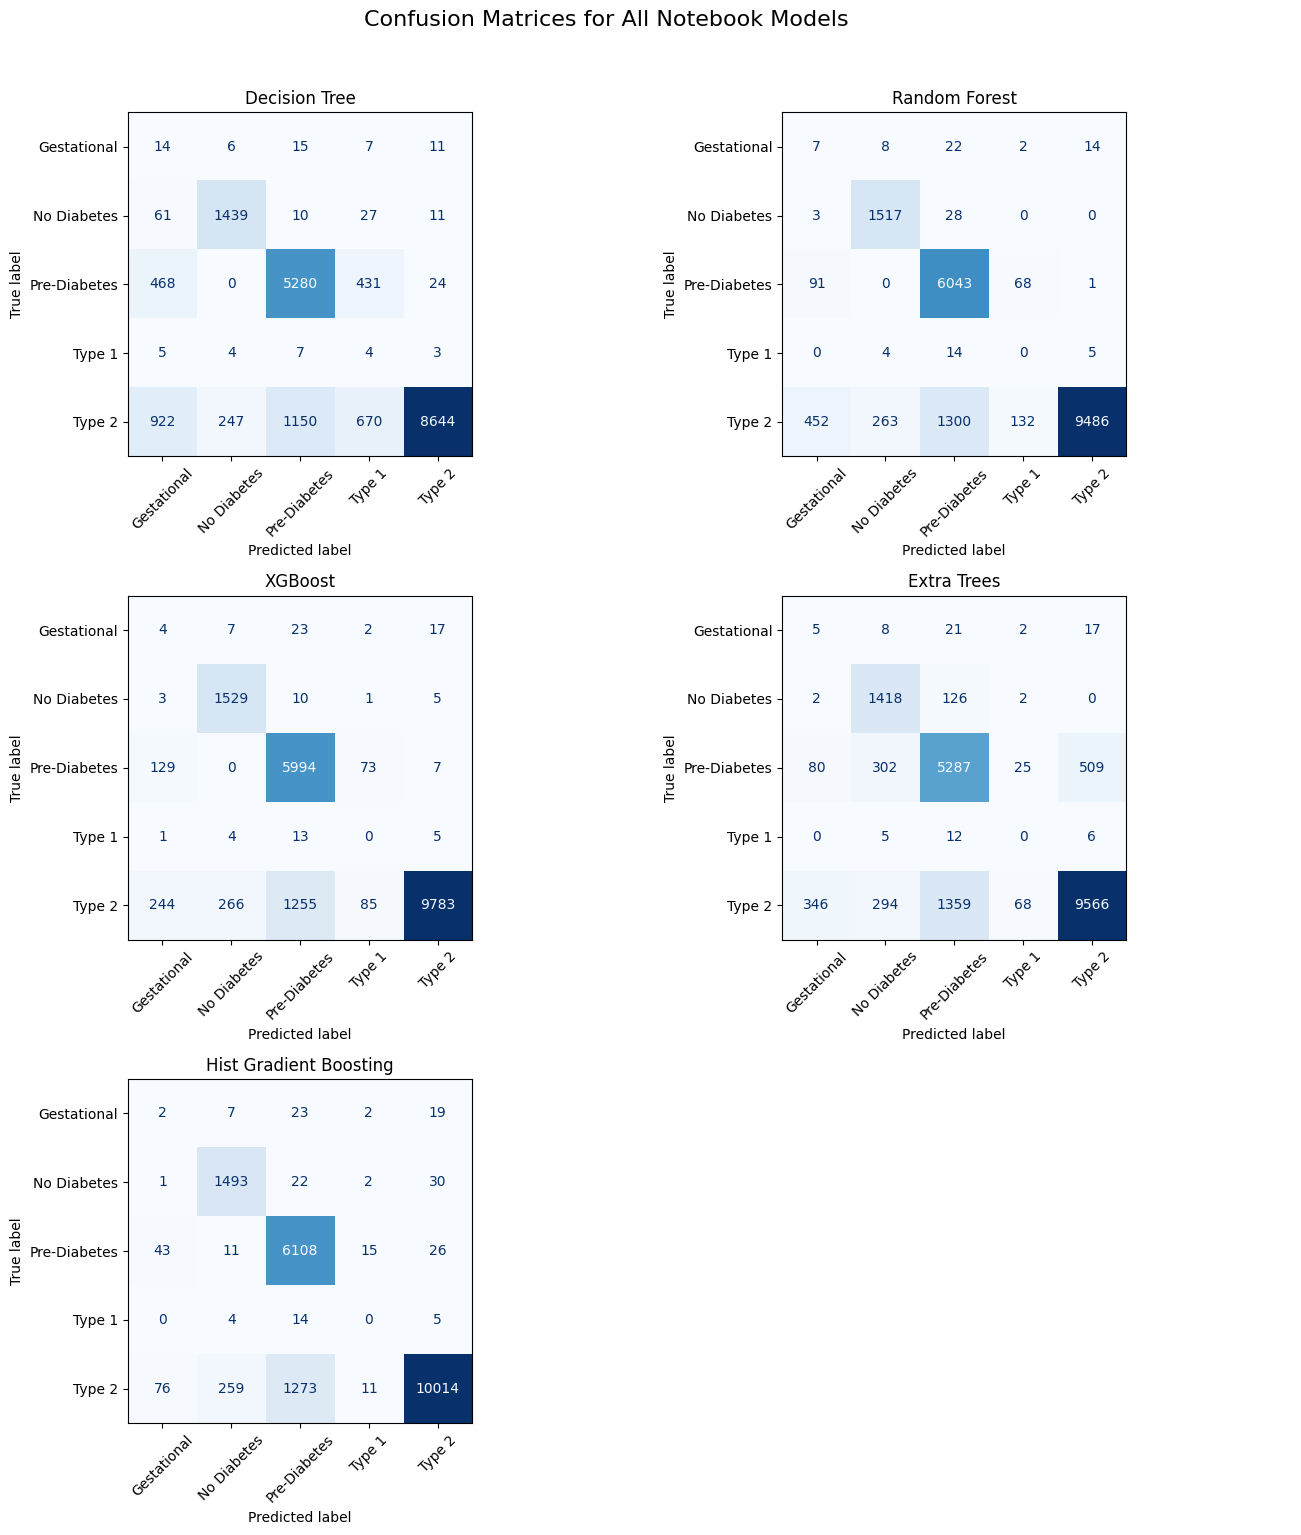

In [6]:
class_names = data["target_encoder"].classes_
model_names = list(evaluations.keys())
columns = 2
rows = int(np.ceil(len(model_names) / columns))

fig, axes = plt.subplots(rows, columns, figsize=(14, 5 * rows))
axes = np.atleast_1d(axes).ravel()

for axis, model_name in zip(axes, model_names):
    ConfusionMatrixDisplay(
        confusion_matrix=evaluations[model_name]["confusion"],
        display_labels=class_names,
    ).plot(ax=axis, cmap="Blues", colorbar=False, values_format="d")
    axis.set_title(model_name)
    axis.tick_params(axis="x", rotation=45)

for axis in axes[len(model_names):]:
    axis.axis("off")

fig.suptitle("Confusion Matrices for All Notebook Models", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [7]:
for model_name, result in evaluations.items():
    print(f"\n{model_name}")
    display(result["report"].round(3))


Decision Tree


,precision,recall,f1-score,support
Gestational,0.010,0.264,0.018,53.00
No Diabetes,0.848,0.930,0.887,1548.00
Pre-Diabetes,0.817,0.851,0.834,6203.00
Type 1,0.004,0.174,0.007,23.00
Type 2,0.994,0.743,0.851,11633.00
accuracy,0.790,0.790,0.790,0.79
macro avg,0.535,0.592,0.519,19460.00
weighted avg,0.922,0.790,0.845,19460.00



Random Forest


,precision,recall,f1-score,support
Gestational,0.013,0.132,0.023,53.000
No Diabetes,0.847,0.980,0.908,1548.000
Pre-Diabetes,0.816,0.974,0.888,6203.000
Type 1,0.000,0.000,0.000,23.000
Type 2,0.998,0.815,0.897,11633.000
accuracy,0.876,0.876,0.876,0.876
macro avg,0.535,0.580,0.543,19460.000
weighted avg,0.924,0.876,0.892,19460.000



XGBoost


,precision,recall,f1-score,support
Gestational,0.010,0.075,0.018,53.00
No Diabetes,0.847,0.988,0.912,1548.00
Pre-Diabetes,0.822,0.966,0.888,6203.00
Type 1,0.000,0.000,0.000,23.00
Type 2,0.997,0.841,0.912,11633.00
accuracy,0.890,0.890,0.890,0.89
macro avg,0.535,0.574,0.546,19460.00
weighted avg,0.925,0.890,0.901,19460.00



Extra Trees


,precision,recall,f1-score,support
Gestational,0.012,0.094,0.021,53.000
No Diabetes,0.700,0.916,0.793,1548.000
Pre-Diabetes,0.777,0.852,0.813,6203.000
Type 1,0.000,0.000,0.000,23.000
Type 2,0.947,0.822,0.880,11633.000
accuracy,0.836,0.836,0.836,0.836
macro avg,0.487,0.537,0.501,19460.000
weighted avg,0.870,0.836,0.849,19460.000



Hist Gradient Boosting


,precision,recall,f1-score,support
Gestational,0.016,0.038,0.023,53.000
No Diabetes,0.842,0.964,0.899,1548.000
Pre-Diabetes,0.821,0.985,0.895,6203.000
Type 1,0.000,0.000,0.000,23.000
Type 2,0.992,0.861,0.922,11633.000
accuracy,0.905,0.905,0.905,0.905
macro avg,0.534,0.570,0.548,19460.000
weighted avg,0.922,0.905,0.908,19460.000


## Patient Segmentation Visuals

This section reuses the patient-segmentation outputs already generated by `src/train_models.py` instead of rebuilding the PCA projection and cluster-label logic inside the notebook.

It shows the saved cluster profile table plus the same cluster size and cluster map images used by the dashboard.

,cluster,physical_activity_minutes_per_week,diet_score,bmi,glucose_fasting,hba1c,cluster_size
0,0,105.49,6.06,24.78,121.52,7.25,22961
1,1,134.52,6.28,23.87,101.21,5.90,29436
2,2,113.77,5.59,28.38,113.14,6.58,25440


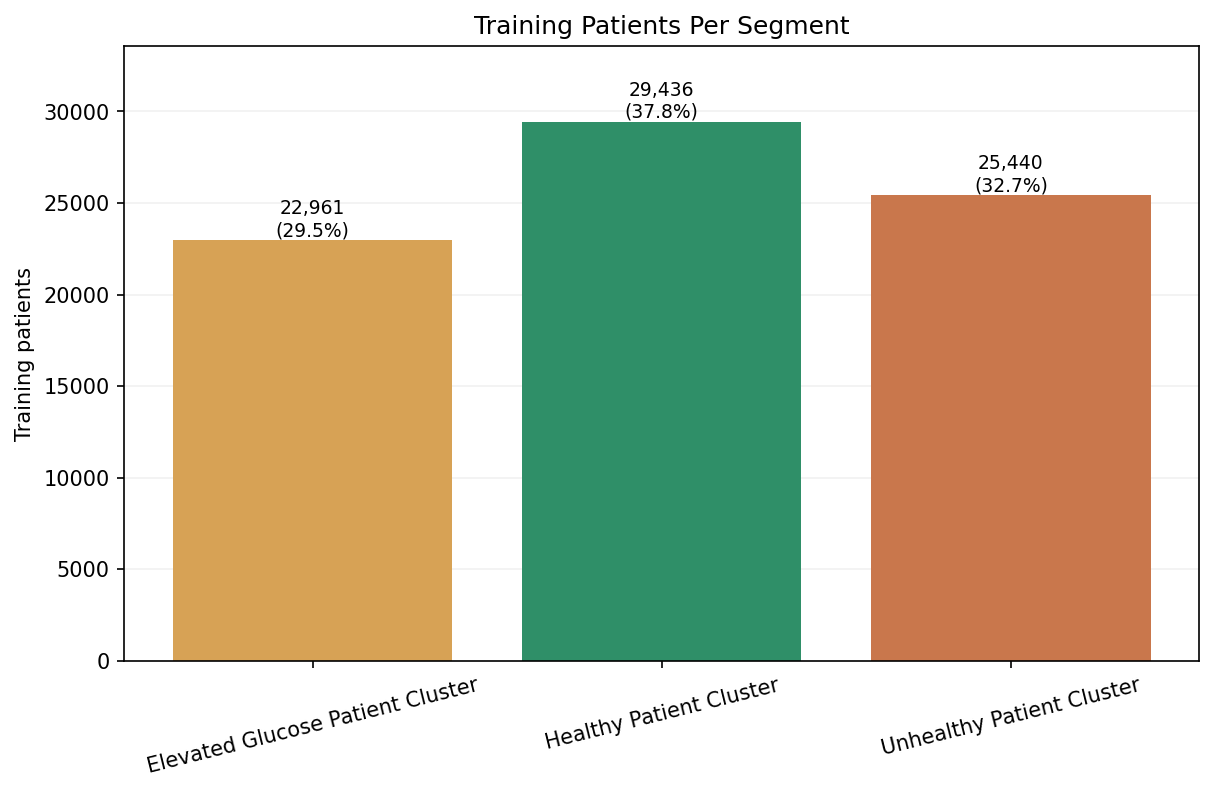

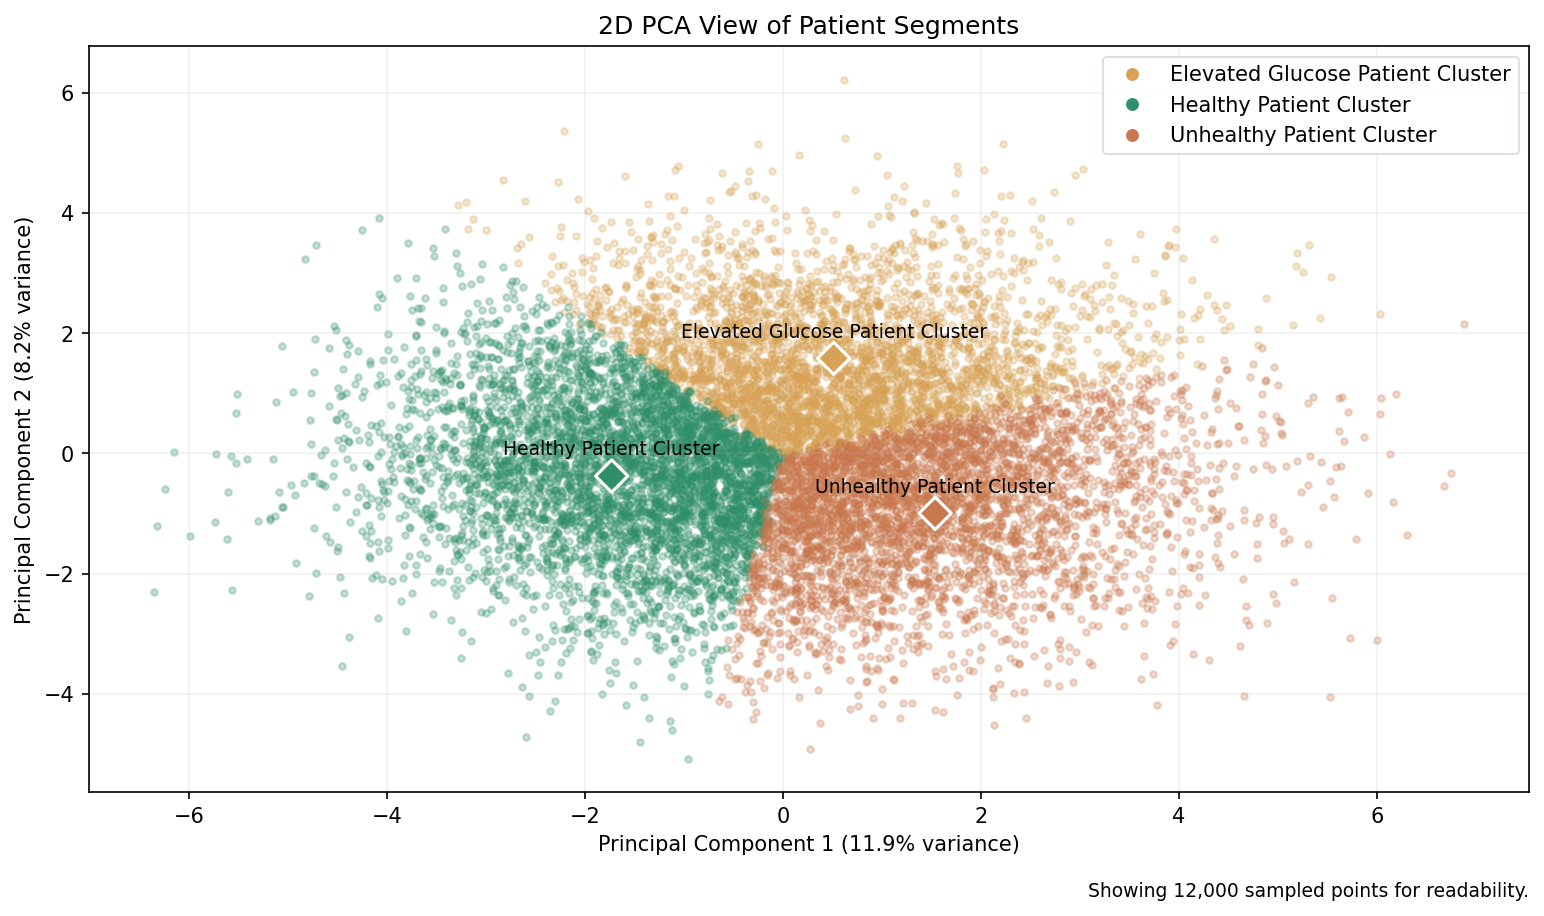

In [8]:
cluster_profiles_path = DATA_DIR / "cluster_profiles.csv"
if not cluster_profiles_path.exists():
    raise FileNotFoundError(
        f"Missing required segmentation file: {cluster_profiles_path}. Run src/train_models.py first."
    )

cluster_profiles = pd.read_csv(cluster_profiles_path).sort_values("cluster").reset_index(drop=True)
display(cluster_profiles)

cluster_size_path, cluster_map_path = get_cluster_visualization_paths()
for image_path in (cluster_size_path, cluster_map_path):
    if not image_path.exists():
        raise FileNotFoundError(
            f"Missing required segmentation image: {image_path}. Run src/train_models.py first."
        )

display(Image(filename=str(cluster_size_path)))
display(Image(filename=str(cluster_map_path)))